In [51]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 0. Device and Range
EUI="ac1f09fffe1e4803"
QUERY_START_DATE="2026-01-01"

# 1. Configuration
API_URL = f"https://api.rriv.org/data/readings/{EUI}?rangeStart={QUERY_START_DATE}"  # Replace with your API endpoint
HEADERS = {}                             # Add API keys/headers if needed, e.g. {"Authorization": "Bearer TOKEN"}

# Specify your column names here
TIME_COL = "timestamp"   # Column containing "2026-07-20T23:01:00"

# 2. Fetch data from API
response = requests.get(API_URL, headers=HEADERS)
response.raise_for_status()              # Raises an error for HTTP failures (4xx or 5xx)
data = response.json()

# -------------------------------------------------------------------------
# Note: Adjust 'data' if the list of objects is nested inside a key
# (e.g., data = response.json()['results'])
# -------------------------------------------------------------------------

# 3. Load into DataFrame
source_df = pd.DataFrame(data)

In [56]:
# 1. Specify Plot Start Date
PLOT_START_DATE="2026-07-06 00:00:00"

# 4. Parse ISO dates and sort chronologically
# Pandas automatically parses ISO 8601 strings (like '2026-07-20T23:01:00') cleanly
source_df[TIME_COL] = pd.to_datetime(source_df[TIME_COL])

# 4.1. Define your filter date
cutoff_date = pd.Timestamp(PLOT_START_DATE).tz_localize("US/Pacific")

# 4.3 Sort the values
source_df[TIME_COL] = source_df[TIME_COL].dt.tz_convert("US/Pacific")
df = source_df.sort_values(TIME_COL)

# 4.2. Filter the DataFrame
# This keeps only rows strictly AFTER the date above
df = df[df[TIME_COL] > cutoff_date]



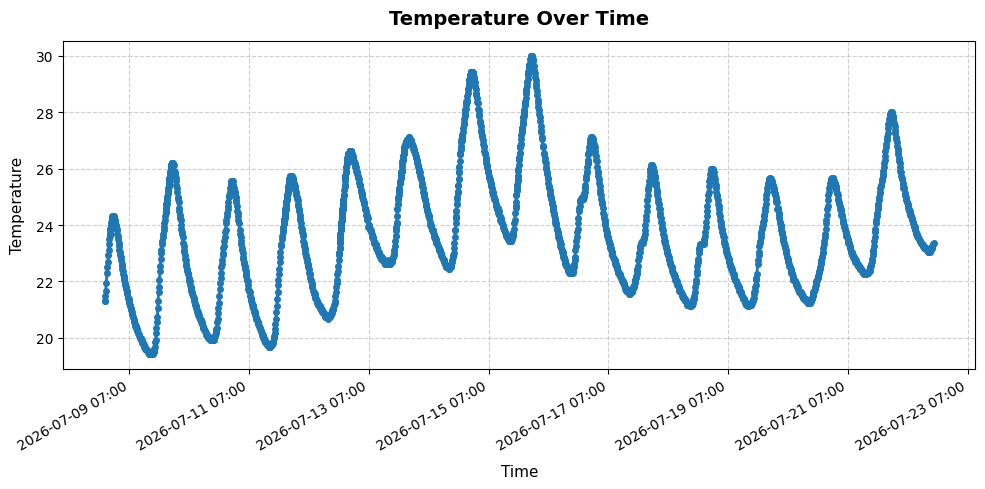

In [58]:
# 5. Plotting
VAL_COL = "value_2"        # Column containing the numeric variable you want to plot
VAL_COL_NAME = "Temperature"

plt.figure(figsize=(10, 5))
plt.plot(df[TIME_COL], df[VAL_COL], color="#1f77b4", linewidth=2, marker="o", markersize=4)

# Format axes
plt.title(f"{VAL_COL_NAME} Over Time", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Time", fontsize=11, labelpad=8)
plt.ylabel(VAL_COL_NAME, fontsize=11, labelpad=8)

# Format X-axis readable dates/times
gca = plt.gca()
gca.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.xticks(rotation=30, ha="right")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Render plot inline in Jupyter
plt.show()

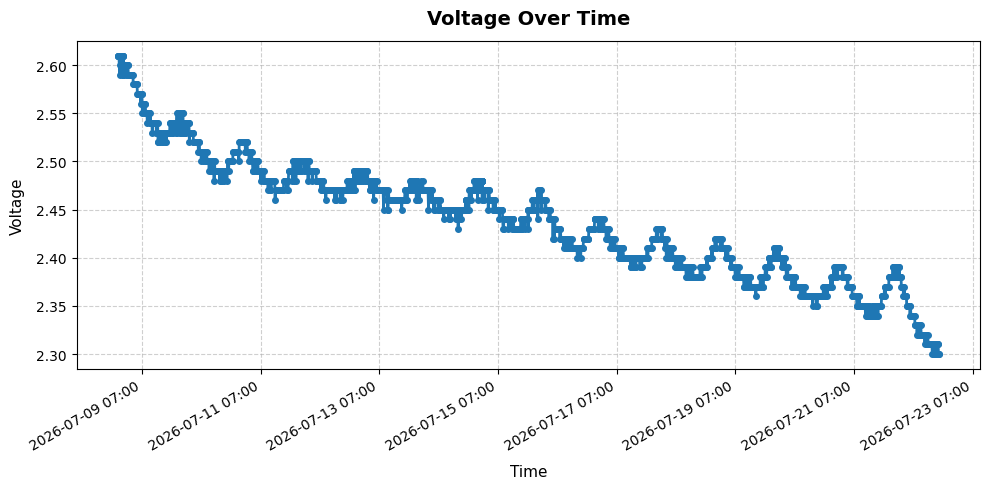

In [57]:
# Specify your column names here
VAL_COL = "value_1"        # Column containing the numeric variable you want to plot
VAL_COL_NAME = "Voltage"


# 5. Plotting
plt.figure(figsize=(10, 5))
plt.plot(df[TIME_COL], df[VAL_COL], color="#1f77b4", linewidth=2, marker="o", markersize=4)

# Format axes
plt.title(f"{VAL_COL_NAME} Over Time", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Time", fontsize=11, labelpad=8)
plt.ylabel(VAL_COL_NAME, fontsize=11, labelpad=8)

# Format X-axis readable dates/times
gca = plt.gca()
gca.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.xticks(rotation=30, ha="right")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Render plot inline in Jupyter
plt.show()